---
title: "📐The Hidden Geometry of Software Coupling (Part 1)"
date: 2026-03-09 00:11:50 -0500
categories:
  - sdlc
  - architecture
  - coupling
  - metrics
author: steven
---

# 📐 The Hidden Geometry of Software Coupling
### Part 1 — The Metrics That Predict Architectural Failure
![📐 The Hidden Geometry of Software Coupling](../assets/images/coupling-sm.png)

In [22]:
# ============================================================
# SETUP — Run this first!
# ============================================================

import base64
import re
from pathlib import Path

import nbformat
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter

print("✅ matplotlib version:", mpl.__version__)
print("✅ Setup complete!")

# ============================================================
# 🎨 ARTICLE STYLE + SHARED CONFIGURATION
# ============================================================

PALETTE = {
    "paper_bg": "#EFE7D6",
    "plot_bg": "#E6DDCB",
    "grid": "#8E8474",
    "axis": "#2E4369",
    "zone_pain": "#B25E5E",
    "zone_useless": "#9086C4",
    "main_seq": "#4DAA57",
    "_guide": "#8A8276",
    "label_bg": "#FCF5E5",
    "danger_text": "#8B0000",
    "distance_text": "#4F4A43",
    "stable_band": "#91B98A",
    "mostly_stable_band": "#B9C98B",
    "borderline_band": "#D9BF74",
    "volatile_band": "#C97C7C",
}

TEXT_STYLE = {
    "title": {
        "fontsize": 23,
        "fontstyle": "italic",
        "family": "DejaVu Serif",
        "color": PALETTE["axis"],
        "pad": 28,
    },
    "subtitle": {
        "fontsize": 18,
        "family": "DejaVu Sans Mono",
        "color": PALETTE["axis"],
    },
    "axis_label": {
        "fontsize": 16,
        "color": PALETTE["axis"],
    },
    "zone_label": {
        "fontsize": 13,
        "family": "DejaVu Serif",
        "fontweight": "semibold",
        "color": PALETTE["danger_text"],
    },
    "point_label": {
        "fontsize": 11,
        "color": PALETTE["axis"],
    },
    "distance_label": {
        "fontsize": 10,
        "color": PALETTE["distance_text"],
    },
    "curve_label": {
        "fontsize": 11,
        "family": "DejaVu Serif",
        "fontweight": "semibold",
    },
}

AXIS_CONFIG = {
    "main_sequence": {
        "xlim": (0.0, 1.0),
        "ylim": (0.0, 1.0),
        "xticks": tuple(np.arange(0.0, 1.01, 0.1)),
        "yticks": tuple(np.arange(0.0, 1.01, 0.1)),
        "xlabel": "I (Instability) →",
        "ylabel": "A (Abstractness) →",
        "aspect": "equal",
        "grid_alpha": 0.20,
        "grid_linewidth": 1.0,
    },
    "instability_curves": {
        "xlim": (0.0, 20.0),
        "ylim": (0.0, 1.02),
        "xticks": (0, 5, 10, 15, 20),
        "yticks": (0.0, 0.25, 0.50, 0.75, 1.0),
        "xlabel": "Ce (Efferent Coupling)",
        "ylabel": "I = Instability",
        "aspect": None,
        "grid_alpha": 0.14,
        "grid_linewidth": 1.0,
    },
}

MODULES = [
    {"name": "Database Schema", "I": 0.10, "A": 0.08, "color": "#E53935"},
    {"name": "Unused Interfaces", "I": 0.70, "A": 0.93, "color": "#1E40FF"},
    {"name": "Core Domain Interfaces", "I": 0.22, "A": 0.78, "color": "#0B8A0B"},
    {"name": "Domain Model", "I": 0.38, "A": 0.52, "color": "#1E8E1E"},
    {"name": "Service Layer", "I": 0.68, "A": 0.36, "color": "#169C16"},
    {"name": "Perfect Balance", "I": 0.50, "A": 0.50, "color": "#006400"},
    {"name": "API Gateway", "I": 0.80, "A": 0.40, "color": "#F4A000"},
    {"name": "Shared Utilities", "I": 0.34, "A": 0.44, "color": "#8A6D3B"},
    {"name": "Integration Adapter", "I": 0.88, "A": 0.12, "color": "#8C564B"},
]
for module in MODULES:
    module["D"] = abs(module["A"] + module["I"] - 1.0)

ZONE_LABELS = {
    "pain": {
        "text": "ZONE OF PAIN\n(Stable + Concrete)",
        "xy": (0.01, 0.10),
        "ha": "left",
        "va": "center",
    },
    "useless": {
        "text": "ZONE OF USELESSNESS\n(Unstable + Abstract)",
        "xy": (0.99, 0.90),
        "ha": "right",
        "va": "center",
    },
}

POINT_LABEL_BASE = {
    "left_of_line": {"dx": -0.045, "dy": 0.00, "ha": "right", "va": "center"},
    "right_of_line": {"dx": 0.045, "dy": 0.00, "ha": "left", "va": "center"},
    "on_line": {"dx": 0.020, "dy": 0.020, "ha": "left", "va": "center"},
}

POINT_LABEL_OVERRIDES = {
    "Database Schema": {"dx": 0.015, "dy": 0.000, "ha": "left", "va": "center"},
    "Unused Interfaces": {"dx": 0.035, "dy": -0.010, "ha": "left", "va": "center"},
    "Core Domain Interfaces": {"dx": -0.040, "dy": 0.015, "ha": "right", "va": "center"},
    "Shared Utilities": {"dx": 0.030, "dy": -0.030, "ha": "left", "va": "center"},
    "Service Layer": {"dx": 0.030, "dy": 0.000, "ha": "left", "va": "center"},
    "Integration Adapter": {"dx": -0.020, "dy": -0.050, "ha": "right", "va": "center"},
}

SHOW_DISTANCE_FOR = {
    "Database Schema",
    "Unused Interfaces",
    "Service Layer",
    "API Gateway",
    "Shared Utilities",
    "Integration Adapter",
}

DISTANCE_LABEL_OFFSETS = {
    "Database Schema": (0.020, 0.055),
    "Unused Interfaces": (-0.045, -0.040),
    "Service Layer": (0.020, -0.028),
    "API Gateway": (0.024, -0.010),
    "Shared Utilities": (-0.030, -0.010),
    "Integration Adapter": (-0.018, -0.022),
}

CURVE_CONFIG = {
    "ca_values": (0, 1, 2, 3, 5, 10, 15, 20),
    "colors": ("#9D1A1A", "#FF2626", "#FF6A00", "#E58A00", "#5EA400", "#0EA5A8", "#2563EB", "#7C3AED"),
    "num_points": 401,
    "label_alpha": 0.58,
    "label_t_values": (0.12, 0.24, 0.34, 0.42, 0.52, 0.62, 0.78, 0.88),
    "label_y_offset": -0.035,
    "legend_anchor": (-0.23, 0.45),
    "band_label_x_offset": 0.45,
    "bands": (
        {"y0": 0.00, "y1": 0.25, "color": PALETTE["stable_band"], "label": "STABLE", "text_color": "#2D7A32"},
        {"y0": 0.25, "y1": 0.50, "color": PALETTE["mostly_stable_band"], "label": "MOSTLY STABLE", "text_color": "#789C2E"},
        {"y0": 0.50, "y1": 0.75, "color": PALETTE["borderline_band"], "label": "BORDERLINE", "text_color": "#A06F00"},
        {"y0": 0.75, "y1": 1.00, "color": PALETTE["volatile_band"], "label": "VOLATILE", "text_color": "#A12F2F"},
    ),
}

mpl.rcParams.update({
    "figure.facecolor": PALETTE["paper_bg"],
    "axes.facecolor": PALETTE["plot_bg"],
    "axes.edgecolor": PALETTE["axis"],
    "axes.labelcolor": PALETTE["axis"],
    "axes.titlecolor": PALETTE["axis"],
    "axes.titleweight": "semibold",
    "xtick.color": PALETTE["axis"],
    "ytick.color": PALETTE["axis"],
    "text.color": PALETTE["axis"],
    "font.size": 12,
    "font.family": "DejaVu Sans",
})

FIGSIZE_MAIN = (10.8, 8.5)
FIGSIZE_DETAIL = (12.2, 9.0)
FIGSIZE_CURVES = (13.0, 8.8)


def tick_fmt(value: float, _tick_position: float) -> str:
    if abs(value - round(value)) < 1e-9:
        return str(int(round(value)))
    return f"{value:.1f}"


TICK_FORMATTER = FuncFormatter(tick_fmt)


def project_to_main_sequence(i_value: float, a_value: float) -> tuple[float, float]:
    projected_i = (i_value - a_value + 1.0) / 2.0
    projected_i = max(0.0, min(1.0, projected_i))
    projected_a = 1.0 - projected_i
    return projected_i, projected_a



def style_axes(
    ax,
    *,
    title: str,
    subtitle: str | None = None,
    axis_config: dict,
    x_label_style: dict | None = None,
    y_label_style: dict | None = None,
    title_style: dict | None = None,
    subtitle_style: dict | None = None,
) -> None:
    cfg = axis_config
    x_label_style = x_label_style or TEXT_STYLE["axis_label"]
    y_label_style = y_label_style or TEXT_STYLE["axis_label"]
    title_style = title_style or TEXT_STYLE["title"]
    subtitle_style = subtitle_style or TEXT_STYLE["subtitle"]

    ax.set_xlim(*cfg["xlim"])
    ax.set_ylim(*cfg["ylim"])
    if cfg.get("aspect"):
        ax.set_aspect(cfg["aspect"], adjustable="box")
    ax.set_xlabel(cfg["xlabel"], labelpad=12, **x_label_style)
    ax.set_ylabel(cfg["ylabel"], labelpad=18, **y_label_style)
    ax.set_xticks(cfg["xticks"])
    ax.set_yticks(cfg["yticks"])
    ax.xaxis.set_major_formatter(TICK_FORMATTER)
    ax.yaxis.set_major_formatter(TICK_FORMATTER)
    ax.grid(True, color=PALETTE["grid"], alpha=cfg.get("grid_alpha", 0.2), linewidth=cfg.get("grid_linewidth", 1.0))
    ax.tick_params(length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETTE["axis"])
    ax.spines["bottom"].set_color(PALETTE["axis"])
    ax.set_title(title, **title_style)
    if subtitle:
        ax.text(
            0.5,
            1.015,
            subtitle,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            zorder=10,
            bbox=dict(facecolor=PALETTE["paper_bg"], edgecolor="none", alpha=0.85, pad=0.2),
            **subtitle_style,
        )



def draw_zones(ax) -> None:
    ax.add_patch(
        Polygon([(0.0, 0.0), (0.0, 0.5), (0.5, 0.0)], closed=True, facecolor=PALETTE["zone_pain"], edgecolor="none", alpha=0.22, zorder=1)
    )
    ax.add_patch(
        Polygon([(1.0, 1.0), (1.0, 0.5), (0.5, 1.0)], closed=True, facecolor=PALETTE["zone_useless"], edgecolor="none", alpha=0.24, zorder=1)
    )
    for zone in ZONE_LABELS.values():
        ax.text(*zone["xy"], zone["text"], ha=zone["ha"], va=zone["va"], zorder=3, **TEXT_STYLE["zone_label"])



def draw_main_sequence(ax, label: str = "Main Sequence") -> None:
    ax.plot([0.0, 1.0], [1.0, 0.0], color=PALETTE["main_seq"], linewidth=4, zorder=2, label=label)



def build_base_legend(include_distance_sample: bool = False) -> list[Line2D]:
    handles = [
        Line2D([0], [0], color=PALETTE["zone_pain"], linewidth=8, alpha=0.22, label="Zone of Pain"),
        Line2D([0], [0], color=PALETTE["zone_useless"], linewidth=8, alpha=0.24, label="Zone of Uselessness"),
        Line2D([0], [0], color=PALETTE["main_seq"], linewidth=4, label="Main Sequence"),
    ]
    if include_distance_sample:
        handles.append(Line2D(
          [0], [0], label="D = Distance from Main Sequence",
          marker="o", markersize=10,  color=PALETTE["main_seq"],
          linestyle="--", linewidth=1.2
        ))

    return handles



def module_side(module: dict) -> str:
    delta = module["A"] + module["I"] - 1.0
    if abs(delta) < 1e-9:
        return "on_line"
    return "left_of_line" if delta > 0 else "right_of_line"



def point_label_position(module: dict) -> tuple[float, float, str, str]:
    base = POINT_LABEL_BASE[module_side(module)].copy()
    override = POINT_LABEL_OVERRIDES.get(module["name"], {})
    for key, value in override.items():
        base[key] = value
    return base["dx"], base["dy"], base["ha"], base["va"]



def render_main_sequence_conceptual() -> None:
    fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
    draw_zones(ax)
    draw_main_sequence(ax)

    ax.plot([0.50, 0.60], [0.50, 0.60], color=PALETTE["main_seq"], linestyle=(0, (2, 3)), linewidth=1.5, alpha=0.85, zorder=2)
    ax.scatter([0.60], [0.60], s=160, color=PALETTE["main_seq"], zorder=4)
    ax.text(0.6, 0.6, "D = Distance from Main Sequence", ha="center", va="center", fontsize=10, family="DejaVu Sans Mono", rotation=-45, color=PALETTE["axis"], zorder=4)

    style_axes(ax, title="Main Sequence", subtitle="A + I = 1", axis_config=AXIS_CONFIG["main_sequence"])
    ax.legend(handles=build_base_legend(include_distance_sample=True), frameon=False, loc="upper left", bbox_to_anchor=(1.08, 1.01), labelcolor=PALETTE["axis"], fontsize=12, borderaxespad=0.0)
    fig.tight_layout(rect=[0.0, 0.0, 0.90, 0.98], pad=1.2)
    plt.show()



def render_distance_from_main_sequence() -> None:
    fig, ax = plt.subplots(figsize=FIGSIZE_DETAIL)
    draw_zones(ax)
    draw_main_sequence(ax)

    for module in MODULES:
        proj_i, proj_a = project_to_main_sequence(module["I"], module["A"])
        ax.plot([module["I"], proj_i], [module["A"], proj_a], color=PALETTE["_guide"], linewidth=1.2, linestyle=(0, (3, 3)), alpha=0.50, zorder=2)
        ax.scatter([proj_i], [proj_a], s=28, color=PALETTE["_guide"], alpha=0.28, zorder=3)

    for module in MODULES:
        ax.scatter([module["I"]], [module["A"]], s=320, color=module["color"], edgecolor="white", linewidth=2.5, zorder=4)
        dx, dy, ha, va = point_label_position(module)
        ax.text(module["I"] + dx, module["A"] + dy, module["name"], ha=ha, va=va, zorder=5, clip_on=True, **TEXT_STYLE["point_label"])

    for module in MODULES:
        if module["name"] not in SHOW_DISTANCE_FOR or module["D"] <= 0.001:
            continue
        proj_i, proj_a = project_to_main_sequence(module["I"], module["A"])
        mid_i = (module["I"] + proj_i) / 2.0
        mid_a = (module["A"] + proj_a) / 2.0
        ddx, ddy = DISTANCE_LABEL_OFFSETS.get(module["name"], (0.0, 0.0))
        ax.text(mid_i + ddx, mid_a + ddy, f"D={module['D']:.2f}", ha="center", va="center", zorder=6, bbox=dict(boxstyle="round,pad=0.18,rounding_size=0.04", fc=PALETTE["label_bg"], ec="none", alpha=0.90), **TEXT_STYLE["distance_label"])

    style_axes(ax, title="Distance from Main Sequence", subtitle="A + I = 1", axis_config=AXIS_CONFIG["main_sequence"])
    ax.legend(handles=build_base_legend(include_distance_sample=False), frameon=False, loc="upper left", bbox_to_anchor=(1.08, 1.01), labelcolor=PALETTE["axis"], fontsize=12, borderaxespad=0.0)
    fig.tight_layout(rect=(0.0, 0.0, 0.90, 0.98), pad=1.2)
    plt.show()



def render_instability_curves() -> None:
    """
    Render the instability-curves chart.

    For each fixed afferent-coupling value `Ca`, the curve is generated from the
    instability formula `I = Ce / (Ce + Ca)` across a sampled range of `Ce`
    values from the x-axis configuration. In other words, each curve answers:
    "if a module has this much incoming responsibility, how unstable does it
    become as outgoing dependencies accumulate?"

    Curves rise faster for small `Ca` because a lightly depended-on module becomes
    volatile quickly as it starts depending on many things. Curves rise more
    slowly for large `Ca` because heavily depended-on modules have more structural
    inertia. All curve-generation and presentation values live in CURVE_CONFIG.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_CURVES)

    for band in CURVE_CONFIG["bands"]:
        ax.axhspan(band["y0"], band["y1"], color=band["color"], alpha=0.10, zorder=0)
    for boundary in (0.25, 0.50, 0.75):
        ax.axhline(boundary, color=PALETTE["grid"], linewidth=1.5, linestyle=(0, (6, 4)), alpha=0.45, zorder=1)

    ce_max = AXIS_CONFIG["instability_curves"]["xlim"][1]
    ce_values = np.linspace(0.0, ce_max, CURVE_CONFIG["num_points"])
    legend_handles: list[Line2D] = []

    for ca_value, color, t_value in zip(CURVE_CONFIG["ca_values"], CURVE_CONFIG["colors"], CURVE_CONFIG["label_t_values"]):
        if ca_value == 0:
            instability_values = np.where(ce_values > 0.0, 1.0, np.nan)
        else:
            instability_values = ce_values / (ce_values + ca_value)
        ax.plot(ce_values, instability_values, color=color, linewidth=2.4, zorder=3)

        x_label = ce_max * t_value
        curve_y = 1.0 if ca_value == 0 else x_label / (x_label + ca_value)
        y_label = curve_y + CURVE_CONFIG["label_y_offset"]
        ax.text(
            x_label,
            y_label,
            f"Ca={ca_value}",
            color=color,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc=PALETTE["label_bg"], ec="none", alpha=CURVE_CONFIG["label_alpha"]),
            **TEXT_STYLE["curve_label"],
        )
        legend_handles.append(Line2D([0], [0], color=color, linewidth=6, label=f"Ca = {ca_value}"))

    x_band_text = ce_max + CURVE_CONFIG["band_label_x_offset"]
    for band in CURVE_CONFIG["bands"]:
        y_mid = (band["y0"] + band["y1"]) / 2.0
        ax.text(x_band_text, y_mid, band["label"], color=band["text_color"], rotation=90, va="center", ha="left", fontsize=10, fontweight="semibold")

    style_axes(ax, title="Coupling Metrics\nInstability Curves", axis_config=AXIS_CONFIG["instability_curves"])
    ax.legend(handles=legend_handles, title="Ca Values", loc="center left", bbox_to_anchor=CURVE_CONFIG["legend_anchor"], frameon=True, facecolor=PALETTE["label_bg"], edgecolor="none", title_fontsize=12, fontsize=10)

    fig.text(0.50, 0.03, r"Figure 2: How Instability (I) varies with coupling    $I = \dfrac{C_e}{C_e + C_a}$", ha="center", va="center", fontsize=14, family="DejaVu Serif", color=PALETTE["axis"], bbox=dict(boxstyle="round,pad=0.45", fc="#C7D6EF", ec="#8AA5D1", alpha=0.95))
    fig.tight_layout(rect=[0.05, 0.07, 0.92, 0.98])
    plt.show()



def render_md(filename: str = "notebook.md", notebook_path: str | None = None) -> Path:
    """
    Export the notebook to markdown including markdown cells and output images,
    but excluding code-cell inputs.
    """
    from nbconvert import MarkdownExporter

    if notebook_path is None:
        candidates = sorted(Path.cwd().glob("*.ipynb"), key=lambda item: item.stat().st_mtime, reverse=True)
        if not candidates:
            raise FileNotFoundError("No .ipynb files found in current directory. Pass notebook_path explicitly.")
        notebook_path = str(candidates[0])

    source_path = Path(notebook_path)
    notebook_node = nbformat.read(str(source_path), as_version=4)

    exporter = MarkdownExporter()
    exporter.exclude_input = True
    exporter.exclude_input_prompt = True
    exporter.exclude_output_prompt = True

    body, resources = exporter.from_notebook_node(notebook_node)
    output_path = Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    body = re.sub(r"\n{3,}", "\n\n", body)
    output_path.write_text(body, encoding="utf-8")

    for name, data in resources.get("outputs", {}).items():
        target = output_path.parent / name
        target.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(data, str):
            try:
                target.write_bytes(base64.b64decode(data))
            except Exception:
                target.write_text(data, encoding="utf-8")
        else:
            target.write_bytes(data)

    print(f"✅ Markdown exported to {output_path}")
    if resources.get("outputs"):
        print(f"✅ Exported {len(resources['outputs'])} output asset(s)")
    return output_path


print("🎨 Configuration loaded")

✅ matplotlib version: 3.10.8
✅ Setup complete!
🎨 Configuration loaded


## 📃Introduction

Software engineers love to talk about architecture in qualitative terms.

- *“This module feels tightly coupled”*
- *“That dependency seems risky”*
- *“This design is flexible”*

But beneath those instincts lies something far more concrete
* 🏗 The structure of software systems **_can be measured_**
* 🏛️ Architectural problems can be predicted and addressed **long before production failures reveal them**.
* 🕰 The formulas behind these metrics have been around since the 1990s
* 🤖 They require no machine learning
* 🧮 Just counting (...and occasionally a little division)


## 🗿The Architecture that was “good enough”… until it opened a hellmouth 👹

_For the first six months, even a year, everything felt fast.  Our Ruby-on-Rails application was humming along and new features were added daily_
* Features shipped quickly
* Bug fixes took hours, not days
* Engineers felt productive

_Then, something strange started happening; it began to shift:_
* A simple change began taking longer
* A feature that should have been isolated to one component suddenly required edits across:
  - seemingly-unrelated code; models, controllers, helpers, serializers, background jobs, etc.

_Then the real symptoms appeared:_
* New engineers joined the team and couldn't make heads or tails of the system.
* Bug fixes triggered unrelated failures.
* A “small refactor” broke three features nobody expected to be connected.
* Every change started to feel dangerous.

## Architecture and Coupling
Eventually they hire an architect, who spends some time with the codebase(s) and running various tools

> Your problem isn’t Rails. Your problem is **coupling**.

All the software engineers had heard of this, of course, but thought of it as a _qualitative_ measurement.  It may have come up a few times since, but had never been _exactly quantified_.  Now here it is in the real world.

The application had quietly evolved into something **infamous**:

### A Tightly Coupled Monolith
>  It's a simple complex system.  Because it's simple, it's prone to cascades, and because it's complex, you can't predict what's going to fail. Or how. -- _"The Expanse"_

**Note:** _Coupling can still be a huge problem even if the software in question is **not** a monolith_


**When software is tightly coupled**
* A change almost anywhere could trigger side effects somewhere else
* Features that should have touched one module required edits across five
* Bug fixes became archaeology

### And the surprising part?
* These structural problems weren't mysterious
* They were **measurable** and **preventable**

## Coupling Metrics
![Coupling Metrics](../assets/images/metrics-sm.png)

### 📐 The Two Numbers That Explain Most Architecture

Nearly every structural coupling metric derives from two simple counts.

```text
        Who depends on me?
                ↑
               Ca
                │
                ● GIVEN MODULE/PACKAGE
                │
               Ce
                ↓
        Upon whom do I depend?
```

### Afferent Coupling (Ca)

```text
Ca = number of external modules that depend on this one
```

Afferent coupling measures **responsibility**.

If many modules depend on you, your stability matters.

Break this module, and others break too.

Modules with high Ca become **structural anchors**.

### Efferent Coupling (Ce)

```text
Ce = number of external modules this module depends on
```

Efferent coupling measures **vulnerability**.

The more dependencies you have, the more ways your code can break.

Every dependency introduces:

- version risk
- semantic assumptions
- upgrade friction

Dependencies are powerful.

But they are never free.

### 🧮 A Simple Analogy

These metrics behave like a financial balance sheet.

| Metric                     | Analogy                        |
|----------------------------|--------------------------------|
| `Ca` *(Afferent Coupling)* | Creditors (who depends on you) |
| `Ce` *(Efferent Coupling)* | Debts (who you depend on)      |

* Modules with many creditors must be **_stable_**.
* Modules with many debts are inherently **_fragile_**.
---

## 🧭 The Instability Index (I)
<img src="../assets/images/metrics-instability-fig1-overview.png"/>

From Ca and Ce we derive a powerful ratio.

```
𝐼 = 𝐶ₑ / (𝐶ₑ + 𝐶ₐ)
```

Instability ranges from **0 to 1**.

| I Range | Stability | Meaning | Change Strategy |
|---|---|---|---|
| 0.0 ≤ I < 0.25 | Stable | Many dependents, few dependencies | Change with care |
| 0.25 ≤ I < 0.50 | Balanced | Healthy structural position | Normal dev pace |
| 0.50 ≤ I < 0.75 | Borderline | Dependency heavy | Monitor closely |
| 0.75 ≤ I ≤ 1.0 | Unstable | Few dependents, many dependencies | Refactor freely |

The graph below shows how instability changes as **Ce** grows for different fixed values of **Ca**.

Low **Ca** produces curves that rise very quickly toward volatility.
Higher **Ca** dampens that rise, making the same increase in **Ce** less destabilizing.

This leads to one of the most important architectural principles.

### Stable Dependencies Principle

Dependencies should flow **toward stability**.

```text
unstable modules  →  stable modules
```

When stable modules depend on unstable ones, architectural fragility appears quickly.


## Instability Curves

The chart above shows how **Instability** changes as **Ce** grows for several fixed values of **Ca**.

A few patterns jump out immediately:

- When **Ca is low**, instability rises very quickly.
  Modules with few dependents become volatile with even a modest increase in outgoing dependencies.
- When **Ca is higher**, the curve climbs more slowly.
  A module with many dependents can absorb some additional dependencies before drifting into the more unstable bands.
- The `Ca = 0` line is the extreme case.
  A module with no dependents is structurally free to become maximally unstable.

This is why **Ce** is not the whole story by itself.
The same number of outgoing dependencies means something different depending on how much responsibility the module already carries.

Said another way: instability is not merely about *how much you depend on* — it is about that dependency load **relative to who depends on you**.

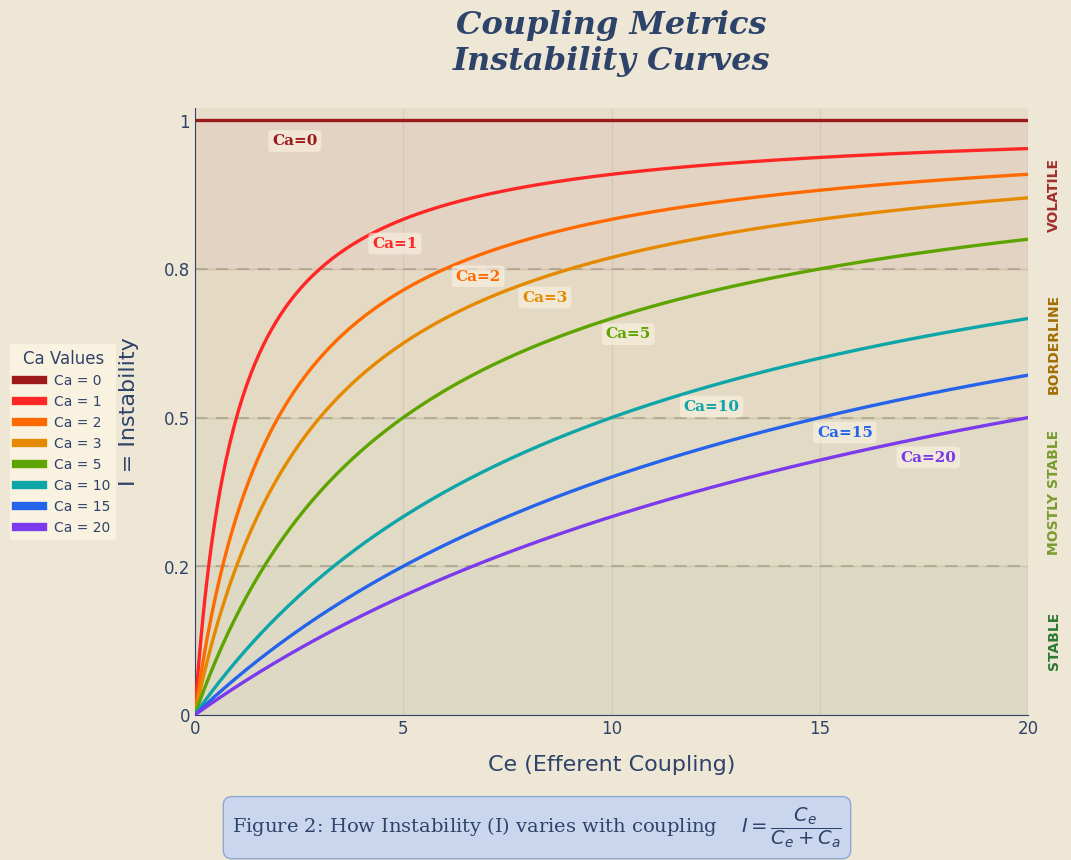

In [23]:
render_instability_curves()

### Description (Instability Curves)
These curves plot the instability formula **I = Ce / (Ce + Ca)** for several fixed values of **Ca**. As **Ce** grows, instability rises; the only question is how quickly. When **Ca** is small, the curve climbs steeply, showing that lightly depended-on modules become volatile fast as they accumulate outgoing dependencies. When **Ca** is large, the curve rises more gradually, showing that heavily depended-on modules have more structural inertia. That is why the chart is useful: it makes the relationship between **responsibility** (`Ca`) and **vulnerability** (`Ce`) visible at a glance. A module near the lower bands is easier to treat as stable infrastructure; a module drifting into the upper bands should be treated as increasingly fragile and more likely to amplify breakage when its dependencies change.


## 🧬 Abstractness (A)

This metric differentiates types as **concrete** or **abstract** (`interface`/`protocol`/`port`).


```text
A = Na / Nc
```

### Where

* ``Na`` = number of abstract types
* ``Nc`` =`total number of types


### Interpretation
* ``A = 1`` → completely abstract
* ``A = 0`` → completely concrete

### Conclusion
* Abstraction provides flexibility
* Concrete code provides behavior
* Good architecture balances both
---

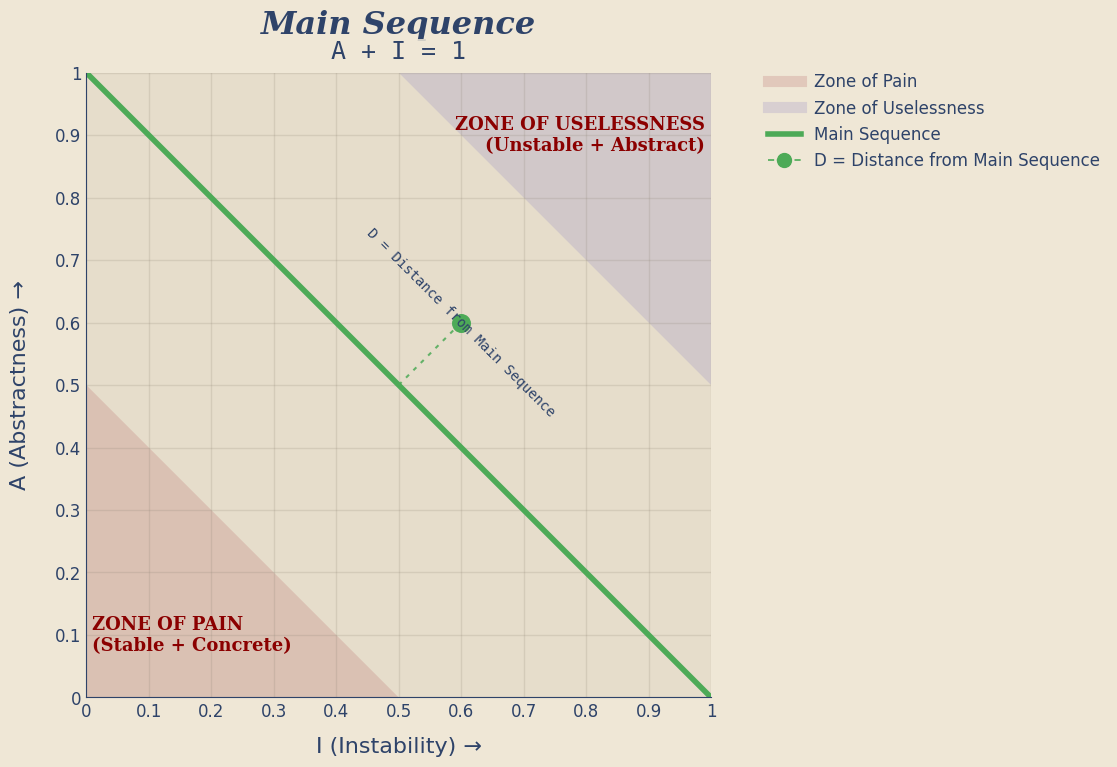

In [24]:
# ============================================================
# 📊 MAIN SEQUENCE — CONCEPTUAL VIEW
# ============================================================
render_main_sequence_conceptual()


## 🧪 The Main Sequence

When plotting **Abstractness (A)** against **Instability (I)**, something interesting appears.

Healthy modules tend to cluster along a line defined by:

```text
A + I = 1
```

This line is called the **Main Sequence**.

The conceptual graph below shows the terrain first:

- the **main-sequence line** itself
- the **Zone of Pain** in the lower-left
- the **Zone of Uselessness** in the upper-right
- a small illustrative distance marker showing how we measure deviation from the line

The key idea is simple: modules do not have to sit exactly on the main sequence, but the farther they drift from it, the more likely they are to be structurally imbalanced.

A quick mental model: the main sequence is the architectural balance line. Concrete modules can afford to be unstable, and abstract modules can afford to be stable. Trouble starts when a module is both rigid and depended on by many others, or highly abstract but used by almost nobody. Distance from the line makes that imbalance measurable.

## 🪨 Architectural Danger Zones

### Zone of Pain

```text
low A
low I
```

Meaning:

```text
concrete AND stable
```

These modules are depended on by many other modules but contain little abstraction.

Examples often include:

- database schemas
- configuration systems
- foundational libraries

Changing them causes cascading impact.

Hence the name.

### Zone of Uselessness

```text
high A
high I
```

Meaning:

```text
abstract AND unstable
```

These modules contain abstractions nobody uses.

Example:

```text
12 interfaces
1 implementation
0 dependents
```

Beautiful architecture.

No real purpose.

## 🧪 Distance From the Main Sequence

Once we place real modules on the same chart, the picture gets richer.

The detailed graph below shows:

- the **main sequence**
- the two architectural danger zones
- example modules in and out of those zones
- a dotted guide line from each module to its nearest point on the main sequence
- the **distance value** (`D`) for the more interesting examples

That lets us see not just *where* a module sits, but *how far off-balance* it is.

Some modules live outside the danger zones and are still worth watching. A service layer, API gateway, or shared utility package may not be pathological, but a non-zero distance still suggests the design is drifting away from the ideal balance.


## 🗺️ Where These Metrics Apply

These metrics apply to many software systems:

- large monoliths
- modular applications
- plugin architectures
- libraries
- microservices

Microservice systems especially benefit from coupling analysis because dependencies often hide behind **network calls rather than imports**.

A service with high efferent coupling may rely on many downstream services.

Each dependency increases operational risk.

Understanding coupling helps prevent systems from drifting toward the dreaded:

```text
distributed monolith
```

## 🧱 The Takeaway

Architecture is often treated as an art.

But beneath the diagrams lies something more mechanical.

Software systems obey structural forces.

Coupling is one of them.

And like gravity…

you can ignore it.

But you cannot escape it.

## 📚 References

- Martin, R. C. (1994). *OO Design Quality Metrics: An Analysis of Dependencies.*
- Martin, R. C. (2017). *Clean Architecture.*
- Lakos, J. (1996). *Large-Scale C++ Software Design.*
- Ford, N., Parsons, R., & Kua, P. (2017). *Building Evolutionary Architectures.*